# 6-0. 전국 신재생 → net_load — 관계 탐색·시계열 분석 (G-9)

> PROJECT.md §5.0.5 / G-9 게이트. **모델 착수 전 필수.** "데이터에 예측 가능한 구조가
> 실제로 있는가 + 무엇을 입력으로 줄 수 있는가"를 본다. 제주 3단계의 전국판.
>
> **타깃**: `gen_solar_utilization_kr`·`gen_wind_utilization_kr`(이용률, 0~1) → ×용량 →
> `net_load = real_demand_land − 신재생`. 학습창 train 2020–2024 / val 2025 / test 2026.
>
> **지점(G-13 확정)**: solar=영광+서산+포항(전남·충남·경북, 용량 61%),
> wind=대관령+영광+포항(강원·경북·전남, 용량 ~90%). 합집합 4지점만 로드.
>
> **점검 항목**: ①데이터 품질·이용률 정의 ②용량 표류(정규화 근거) ③시계열 구조(태양광 일주기·
> 풍력 자기상관 붕괴) ④지점별 기상↔이용률 관계(공간평균 타당성) ⑤흐린날 vs 맑은날(태양광)
> ⑥서빙 가능 피처(후처리 불가 입증) ⑦train↔test 분포 겹침 ⑧net_load 구성. 산출: 그림+표+REPORT.

In [1]:
import os, sqlite3, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
warnings.filterwarnings('ignore')
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110

HERE = os.getcwd()
FIG = os.path.join(HERE, 'fig'); os.makedirs(FIG, exist_ok=True)
TAB = os.path.join(HERE, 'tab'); os.makedirs(TAB, exist_ok=True)
DB = os.path.normpath(os.path.join(HERE, '..', '..',
        '1. data_fetcher_and_db', 'data', 'input_data_land.db'))

# 지점 (G-13 확정)
SOLAR_ST = ['yeonggwang', 'seosan', 'pohang']        # 전남·충남·경북 (용량 61%)
WIND_ST  = ['daegwallyeong', 'yeonggwang', 'pohang'] # 강원·경북·전남 (용량 ~90%)
ALL_ST = sorted(set(SOLAR_ST) | set(WIND_ST))
KOR = {'daegwallyeong':'대관령(강원)','wonju':'원주(강원)','seosan':'서산(충남)',
       'pohang':'포항(경북)','yeonggwang':'영광(전남)'}

base = ['timestamp', 'real_demand_land', 'land_est_demand_da', 'day_type',
        'net_load_kr', 'renew_gen_total_kr', 'gen_total_kr',
        'gen_solar_utilization_kr', 'gen_wind_utilization_kr',
        'gen_solar_capacity_kr', 'gen_wind_capacity_kr',
        'gen_solar_market_kr', 'gen_solar_btm_kr', 'gen_solar_ppa_kr',
        'gen_wind_kr', 'gen_nre_kr', 'gen_hydro_kr']
wx = []
for st in ALL_ST:
    wx += [f'solar_rad_{st}', f'total_cloud_{st}', f'midlow_cloud_{st}',
           f'temp_c_{st}', f'wind_spd_{st}', f'wd_sin_{st}', f'wd_cos_{st}']
con = sqlite3.connect(DB)
df = pd.read_sql(f"SELECT {', '.join(base+wx)} FROM historical", con, parse_dates=['timestamp'])
con.close()
df = df.sort_values('timestamp').reset_index(drop=True)
for c in df.columns:
    if c != 'timestamp': df[c] = pd.to_numeric(df[c], errors='coerce')

# 선택 지점 공간평균 (입력 후보)
df['solar_rad'] = df[[f'solar_rad_{s}' for s in SOLAR_ST]].mean(axis=1)
df['total_cloud_s'] = df[[f'total_cloud_{s}' for s in SOLAR_ST]].mean(axis=1)
df['midlow_cloud_s'] = df[[f'midlow_cloud_{s}' for s in SOLAR_ST]].mean(axis=1)
df['wind_spd'] = df[[f'wind_spd_{s}' for s in WIND_ST]].mean(axis=1)
df['year'] = df.timestamp.dt.year
df['month'] = df.timestamp.dt.month
df['hour'] = df.timestamp.dt.hour
df['doy'] = df.timestamp.dt.dayofyear
df['date'] = df.timestamp.dt.normalize()
print(df.shape, df.timestamp.min(), '~', df.timestamp.max())
df[['timestamp','gen_solar_utilization_kr','gen_wind_utilization_kr',
    'gen_solar_capacity_kr','net_load_kr']].head()

(56352, 54) 2020-01-01 00:00:00 ~ 2026-06-05 23:00:00


,timestamp,gen_solar_utilization_kr,gen_wind_utilization_kr,gen_solar_capacity_kr,net_load_kr
0,2020-01-01 00:00:00,0.001508,0.700180,2745.66,63157.246
1,2020-01-01 01:00:00,0.001231,0.670873,2745.66,60720.400
2,2020-01-01 02:00:00,0.000801,0.604950,2745.66,58714.196
3,2020-01-01 03:00:00,0.000102,0.609977,2745.66,57426.045
4,2020-01-01 04:00:00,0.000142,0.594592,2745.66,57165.515


## 1. 데이터 품질 & 이용률 정의 확인

이용률(0~1) 결측·이상치 점검. 그리고 DB의 `gen_solar_utilization_kr` 가 어떻게 정의됐는지
(= 총발전 / 용량 인지) 역산해 확인한다 — 서빙에서 이용률→발전량 복원에 직결.

In [2]:
for tgt in ['gen_solar_utilization_kr','gen_wind_utilization_kr']:
    u = df[tgt]
    print('%s : NaN=%d  <0=%d  >1=%d  min=%.3f  max=%.3f  mean=%.3f'
          % (tgt, u.isna().sum(), (u<0).sum(), (u>1).sum(), u.min(), u.max(), u.mean()))

# 이용률 정의 역산: util*cap 이 어떤 발전량과 일치하는가?
g = df.dropna(subset=['gen_solar_utilization_kr','gen_solar_capacity_kr']).copy()
g['solar_gen_recon'] = g['gen_solar_utilization_kr'] * g['gen_solar_capacity_kr']
g['solar_total'] = g[['gen_solar_market_kr','gen_solar_btm_kr','gen_solar_ppa_kr']].sum(axis=1)
print('\n[태양광] util*cap vs ...')
for c in ['solar_total','gen_solar_market_kr']:
    print('  corr(util*cap, %-20s) = %.4f  비율중앙값 %.3f'
          % (c, g['solar_gen_recon'].corr(g[c]), (g[c]/g['solar_gen_recon'].replace(0,np.nan)).median()))
w = df.dropna(subset=['gen_wind_utilization_kr','gen_wind_capacity_kr']).copy()
w['wind_gen_recon'] = w['gen_wind_utilization_kr'] * w['gen_wind_capacity_kr']
print('[풍력]   corr(util*cap, gen_wind_kr) = %.4f  비율중앙값 %.3f'
      % (w['wind_gen_recon'].corr(w['gen_wind_kr']), (w['gen_wind_kr']/w['wind_gen_recon'].replace(0,np.nan)).median()))

gen_solar_utilization_kr : NaN=50  <0=0  >1=0  min=0.000  max=1.000  mean=0.187
gen_wind_utilization_kr : NaN=10  <0=0  >1=0  min=0.000  max=1.000  mean=0.301

[태양광] util*cap vs ...
  corr(util*cap, solar_total         ) = 0.8560  비율중앙값 1.000
  corr(util*cap, gen_solar_market_kr ) = 1.0000  비율중앙값 1.000
[풍력]   corr(util*cap, gen_wind_kr) = 1.0000  비율중앙값 1.000


## 2. 용량 표류 → 이용률 정규화 근거 (★)

태양광 설비는 매년 급증한다. 절대 발전량을 학습하면 용량 증설을 모델이 외삽해야 해 부적합.
이용률(발전량/용량)로 정규화하면 연도 안정. 제주 3단계·7-A2 와 동일 논리.

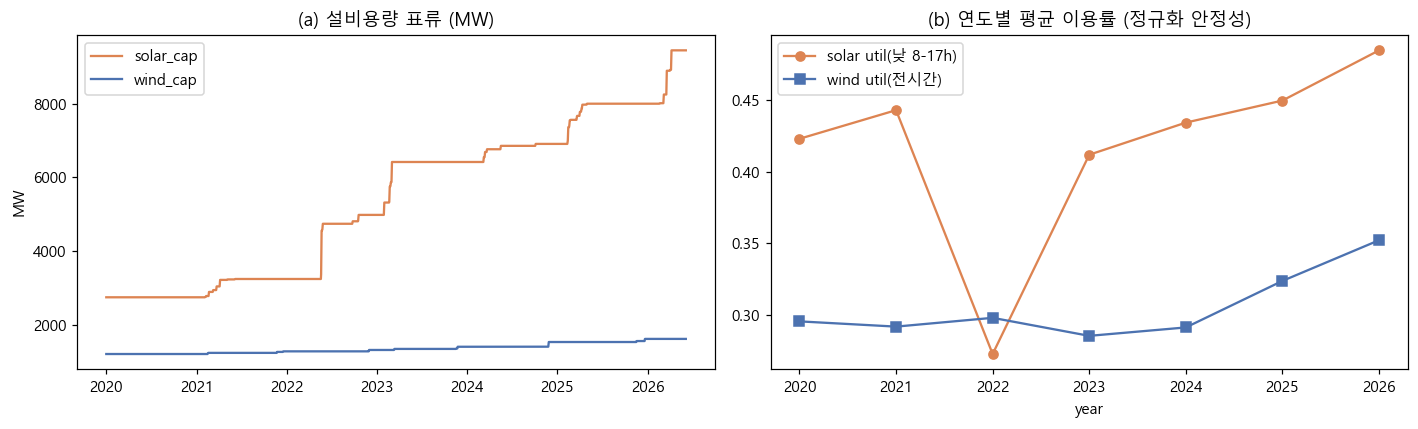

      solar_cap_MW  wind_cap_MW  solar_util_day  wind_util
2020        2746.0       1208.0           0.423      0.296
2021        3137.0       1238.0           0.443      0.292
2022        4215.0       1283.0           0.273      0.298
2023        6217.0       1347.0           0.412      0.286
2024        6762.0       1417.0           0.434      0.292
2025        7803.0       1538.0           0.449      0.324
2026        8676.0       1617.0           0.484      0.352

solar_cap 표류 배수: 3.44x | wind_cap 표류 배수: 1.34x


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
cap = df.groupby('date')[['gen_solar_capacity_kr','gen_wind_capacity_kr']].mean()
ax[0].plot(cap.index, cap['gen_solar_capacity_kr'], label='solar_cap', color='#DD8452')
ax[0].plot(cap.index, cap['gen_wind_capacity_kr'], label='wind_cap', color='#4C72B0')
ax[0].set_title('(a) 설비용량 표류 (MW)'); ax[0].set_ylabel('MW'); ax[0].legend()
# 연도별 이용률 평균(정규화하면 안정?) — 낮시간 태양광
day = df[(df.hour>=8)&(df.hour<=17)]
su = day.groupby('year').gen_solar_utilization_kr.mean()
wu = df.groupby('year').gen_wind_utilization_kr.mean()
ax[1].plot(su.index, su.values, 'o-', label='solar util(낮 8-17h)', color='#DD8452')
ax[1].plot(wu.index, wu.values, 's-', label='wind util(전시간)', color='#4C72B0')
ax[1].set_title('(b) 연도별 평균 이용률 (정규화 안정성)'); ax[1].set_xlabel('year'); ax[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG,'6-0_capacity_drift.png'), bbox_inches='tight'); plt.show()
tab = pd.DataFrame({'solar_cap_MW': cap['gen_solar_capacity_kr'].groupby(cap.index.year).mean().round(0),
                    'wind_cap_MW':  cap['gen_wind_capacity_kr'].groupby(cap.index.year).mean().round(0),
                    'solar_util_day': su.round(3), 'wind_util': wu.round(3)})
tab.to_csv(os.path.join(TAB,'6-0_capacity_util_byyear.csv'))
print(tab.to_string())
print('\nsolar_cap 표류 배수: %.2fx | wind_cap 표류 배수: %.2fx'
      % (cap['gen_solar_capacity_kr'].max()/cap['gen_solar_capacity_kr'].min(),
         cap['gen_wind_capacity_kr'].max()/cap['gen_wind_capacity_kr'].min()))

## 3. 시계열 구조 — 태양광 일주기 / 풍력 자기상관

- 태양광: 강한 일주기(밤=0, 정오 피크) + 계절. 일사·구름이 주동인.
- 풍력: 일주기 약함, **자기상관이 24h 이후 빠르게 붕괴**하면 재귀 롤링 장지평이 불리(3단계 제주 관찰).
  direct(지평별) 설계 근거가 된다.

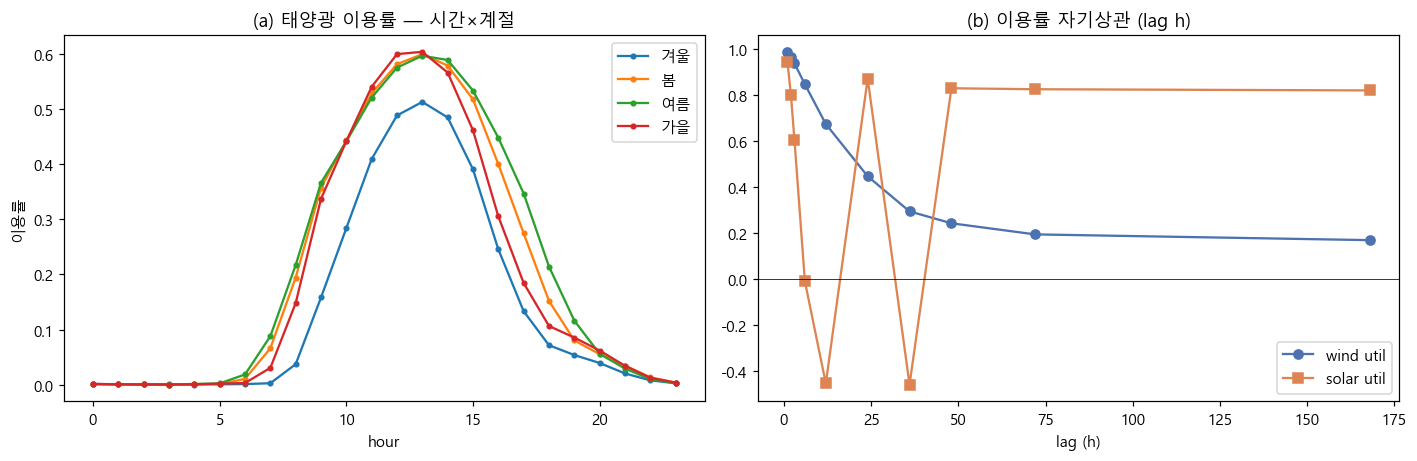

풍력 자기상관: lag1=0.987 lag24=0.447 lag48=0.243 → 24h 후 붕괴 정도 = 0.447→0.243
태양광 자기상관: lag24=0.871 lag168=0.820


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.3))
d2 = df.copy()
d2['season'] = d2.month.map({12:'겨울',1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',
                             6:'여름',7:'여름',8:'여름',9:'가을',10:'가을',11:'가을'})
for s in ['겨울','봄','여름','가을']:
    p = d2[d2.season==s].groupby('hour').gen_solar_utilization_kr.mean()
    ax[0].plot(p.index, p.values, marker='o', ms=3, label=s)
ax[0].set_title('(a) 태양광 이용률 — 시간×계절'); ax[0].set_xlabel('hour'); ax[0].set_ylabel('이용률'); ax[0].legend()
# 풍력 자기상관
sw = df.set_index('timestamp').gen_wind_utilization_kr
ss = df.set_index('timestamp').gen_solar_utilization_kr
lags = [1,2,3,6,12,24,36,48,72,168]
ac_w = [sw.autocorr(L) for L in lags]; ac_s = [ss.autocorr(L) for L in lags]
ax[1].plot(lags, ac_w, 'o-', label='wind util', color='#4C72B0')
ax[1].plot(lags, ac_s, 's-', label='solar util', color='#DD8452')
ax[1].axhline(0, color='k', lw=.5); ax[1].set_title('(b) 이용률 자기상관 (lag h)')
ax[1].set_xlabel('lag (h)'); ax[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG,'6-0_timeseries.png'), bbox_inches='tight'); plt.show()
print('풍력 자기상관: lag1=%.3f lag24=%.3f lag48=%.3f → 24h 후 붕괴 정도 = %.3f→%.3f'
      % (sw.autocorr(1), sw.autocorr(24), sw.autocorr(48), sw.autocorr(24), sw.autocorr(48)))
print('태양광 자기상관: lag24=%.3f lag168=%.3f' % (ss.autocorr(24), ss.autocorr(168)))

## 4. 지점별 기상 ↔ 이용률 관계 & 공간평균 타당성 (★)

G-13 지점 선정의 EDA 검증. 각 지점 단독 vs 선택 지점 공간평균의 상관을 비교 —
평균이 단일지점보다 나으면 공간평균 입력이 타당(제주 3지점 평균 교훈).

In [5]:
day = df[(df.hour>=8)&(df.hour<=17)].copy()
# 태양광: solar_rad, cloud
print('=== 태양광 (낮 8-17h) ===')
rows=[]
for st in ALL_ST:
    rows.append(dict(지점=KOR[st], 선정='solar' if st in SOLAR_ST else '',
        rad_corr=round(day[f'solar_rad_{st}'].corr(day.gen_solar_utilization_kr),3),
        cloud_corr=round(day[f'total_cloud_{st}'].corr(day.gen_solar_utilization_kr),3)))
rows.append(dict(지점='■선택3지점 평균', 선정='★',
    rad_corr=round(day['solar_rad'].corr(day.gen_solar_utilization_kr),3),
    cloud_corr=round(day['total_cloud_s'].corr(day.gen_solar_utilization_kr),3)))
solar_corr = pd.DataFrame(rows); solar_corr.to_csv(os.path.join(TAB,'6-0_solar_station_corr.csv'), index=False)
print(solar_corr.to_string(index=False))
print('\n=== 풍력 (전시간) ===')
rows=[]
for st in ALL_ST:
    rows.append(dict(지점=KOR[st], 선정='wind' if st in WIND_ST else '',
        spd_corr=round(df[f'wind_spd_{st}'].corr(df.gen_wind_utilization_kr),3)))
rows.append(dict(지점='■선택3지점 평균', 선정='★',
    spd_corr=round(df['wind_spd'].corr(df.gen_wind_utilization_kr),3)))
wind_corr = pd.DataFrame(rows); wind_corr.to_csv(os.path.join(TAB,'6-0_wind_station_corr.csv'), index=False)
print(wind_corr.to_string(index=False))

=== 태양광 (낮 8-17h) ===
       지점    선정  rad_corr  cloud_corr
  대관령(강원)           0.656      -0.227
   포항(경북) solar     0.690      -0.275
   서산(충남) solar     0.722      -0.359
   영광(전남) solar     0.754      -0.404
■선택3지점 평균     ★     0.786      -0.414

=== 풍력 (전시간) ===
       지점   선정  spd_corr
  대관령(강원) wind     0.607
   포항(경북) wind     0.345
   서산(충남)          0.424
   영광(전남) wind     0.449
■선택3지점 평균    ★     0.641


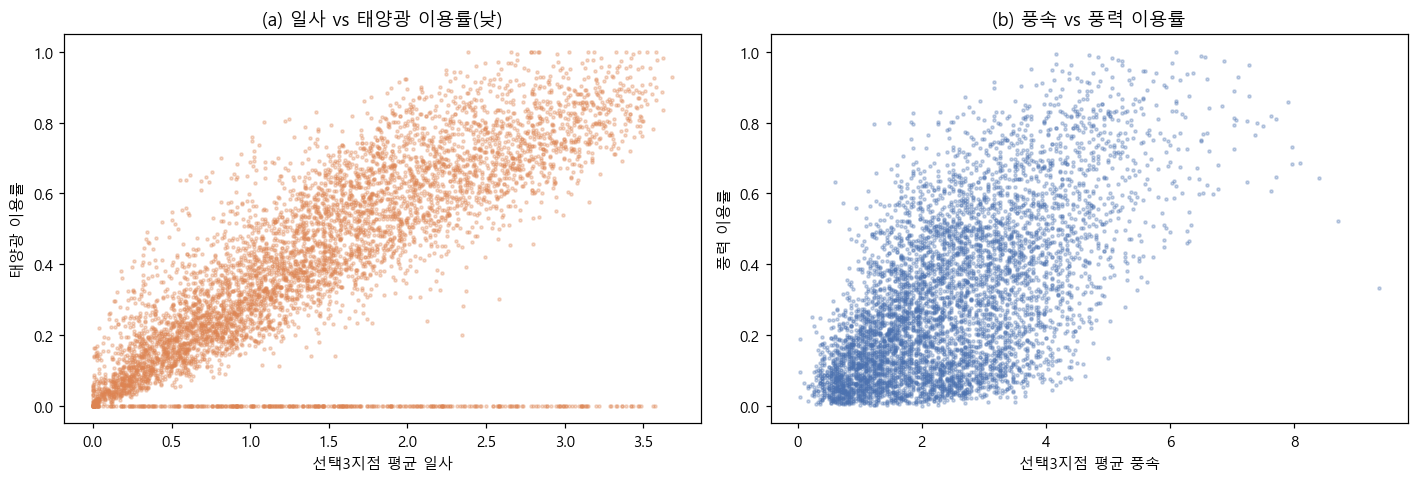

In [6]:
# 산점도: 주동인 1개씩
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
sm = day.sample(min(6000,len(day)), random_state=0)
ax[0].scatter(sm.solar_rad, sm.gen_solar_utilization_kr, s=4, alpha=.3, color='#DD8452')
ax[0].set_xlabel('선택3지점 평균 일사'); ax[0].set_ylabel('태양광 이용률'); ax[0].set_title('(a) 일사 vs 태양광 이용률(낮)')
wm = df.sample(min(6000,len(df)), random_state=0)
ax[1].scatter(wm.wind_spd, wm.gen_wind_utilization_kr, s=4, alpha=.3, color='#4C72B0')
ax[1].set_xlabel('선택3지점 평균 풍속'); ax[1].set_ylabel('풍력 이용률'); ax[1].set_title('(b) 풍속 vs 풍력 이용률')
plt.tight_layout(); plt.savefig(os.path.join(FIG,'6-0_weather_util_scatter.png'), bbox_inches='tight'); plt.show()

## 5. 태양광 흐린날 vs 맑은날 (예보 의존 구간)

제주에서 흐린날 surge 가 약점이었다. 전국도 흐린날 분포·이용률 차이를 본다.
(후처리는 land forecast에 강수·cape 가 없어 불가 — 모델 입력의 구름 변수로만 대응 가능.)

맑은날(하위33% 구름) n=781  정오근방 평균이용률 0.521
흐린날(상위33% 구름) n=807  평균이용률 0.268
흐림/맑음 이용률 비 = 0.51


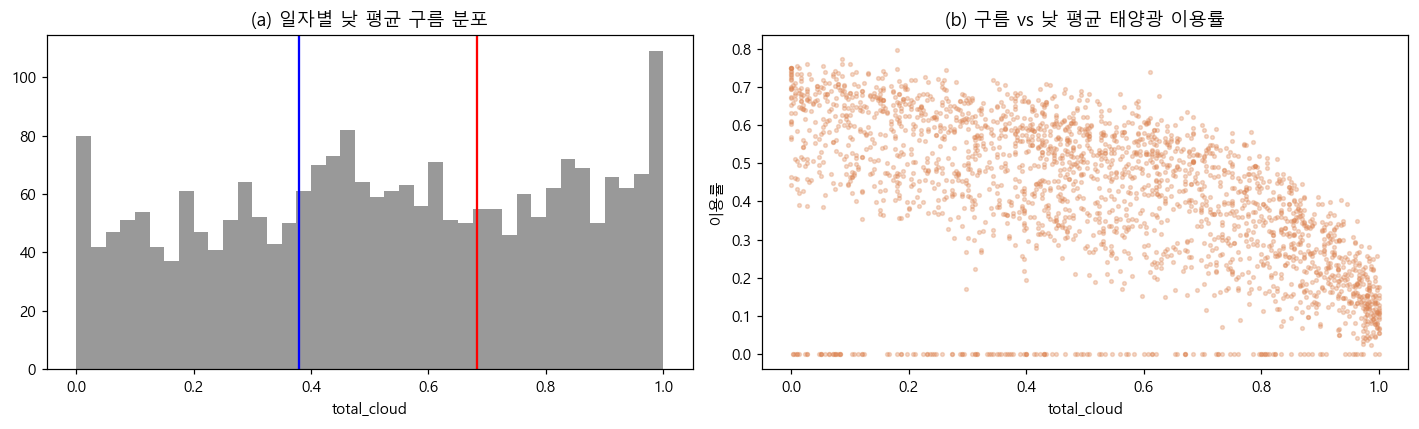

In [7]:
# 일자별 낮 평균 구름으로 맑음/흐림 분류
dday = day.groupby('date').agg(cloud=('total_cloud_s','mean'),
                               util=('gen_solar_utilization_kr','mean')).dropna()
q1, q3 = dday.cloud.quantile([.33,.66])
clear = dday[dday.cloud<=q1]; cloudy = dday[dday.cloud>=q3]
print('맑은날(하위33%% 구름) n=%d  정오근방 평균이용률 %.3f' % (len(clear), clear.util.mean()))
print('흐린날(상위33%% 구름) n=%d  평균이용률 %.3f' % (len(cloudy), cloudy.util.mean()))
print('흐림/맑음 이용률 비 = %.2f' % (cloudy.util.mean()/clear.util.mean()))
fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].hist(dday.cloud, bins=40, color='#999'); ax[0].axvline(q1,color='b'); ax[0].axvline(q3,color='r')
ax[0].set_title('(a) 일자별 낮 평균 구름 분포'); ax[0].set_xlabel('total_cloud')
ax[1].scatter(dday.cloud, dday.util, s=6, alpha=.3, color='#DD8452')
ax[1].set_title('(b) 구름 vs 낮 평균 태양광 이용률'); ax[1].set_xlabel('total_cloud'); ax[1].set_ylabel('이용률')
plt.tight_layout(); plt.savefig(os.path.join(FIG,'6-0_cloudy_clear.png'), bbox_inches='tight'); plt.show()

## 6. 서빙 가능 피처 — 예보 vs 실측 (★ 후처리 불가 입증)

모델 입력은 **forecast 테이블에도 있는 변수만** 써야 D+1 서빙이 된다. land forecast 에
무엇이 있고 없는지(강수·cape·tcog 부재 → 제주식 후처리 불가)를 명시한다.

In [8]:
con = sqlite3.connect(DB)
fc = pd.read_sql('SELECT * FROM forecast', con, parse_dates=['timestamp']); con.close()
fc_bases = set()
for c in fc.columns:
    parts = c.rsplit('_', 1)
    fc_bases.add(parts[0] if parts[-1] in ['daegwallyeong','wonju','seosan','pohang','yeonggwang'] else c)
mapping = [('solar_rad(일사)','radiation'),('total_cloud(전운량)','total_cloud'),
           ('midlow_cloud(중하층운)','midlow_cloud'),('temp_c(기온)','temp'),
           ('wind_spd(풍속)','wind_spd_10m'),('wd_sin/cos(풍향)','wd_sin_10m'),
           ('humidity(습도)','humidity'),('rainfall(강수)','rainfall'),
           ('snow_depth(적설)','snow_depth'),('cape/tcog(후처리용)','cape')]
rows=[]
for hname, fbase in mapping:
    avail = any(fbase==b or c.startswith(fbase) for c in fc.columns for b in [fbase])
    avail = any(fbase in c for c in fc.columns)
    rows.append(dict(변수=hname, forecast키=fbase, 서빙가능=('O' if avail else 'X')))
avail_tab = pd.DataFrame(rows); avail_tab.to_csv(os.path.join(TAB,'6-0_feature_availability.csv'), index=False)
print(avail_tab.to_string(index=False))
print('\nforecast 범위:', fc.timestamp.min(),'~',fc.timestamp.max(),' rows=',len(fc))
print('forecast 컬럼 base 집합:', sorted(fc_bases))

                변수    forecast키 서빙가능
     solar_rad(일사)    radiation    O
  total_cloud(전운량)  total_cloud    O
midlow_cloud(중하층운) midlow_cloud    O
        temp_c(기온)         temp    O
      wind_spd(풍속) wind_spd_10m    O
    wd_sin/cos(풍향)   wd_sin_10m    O
      humidity(습도)     humidity    X
      rainfall(강수)     rainfall    X
    snow_depth(적설)   snow_depth    X
   cape/tcog(후처리용)         cape    X

forecast 범위: 2025-12-10 00:00:00 ~ 2026-06-06 23:00:00  rows= 4296
forecast 컬럼 base 집합: ['day_type', 'land_est_demand_da', 'midlow_cloud', 'radiation', 'smp_land_da', 'temp', 'timestamp', 'total_cloud', 'wd_cos_10m', 'wd_sin_10m', 'wind_spd_10m']


## 7. train ↔ test 분포 겹침 (covariate shift)

train(2020–2024) 과 test(2026) 의 입력(일사·풍속)·타깃(이용률) 분포가 겹쳐야 정직한 검증.

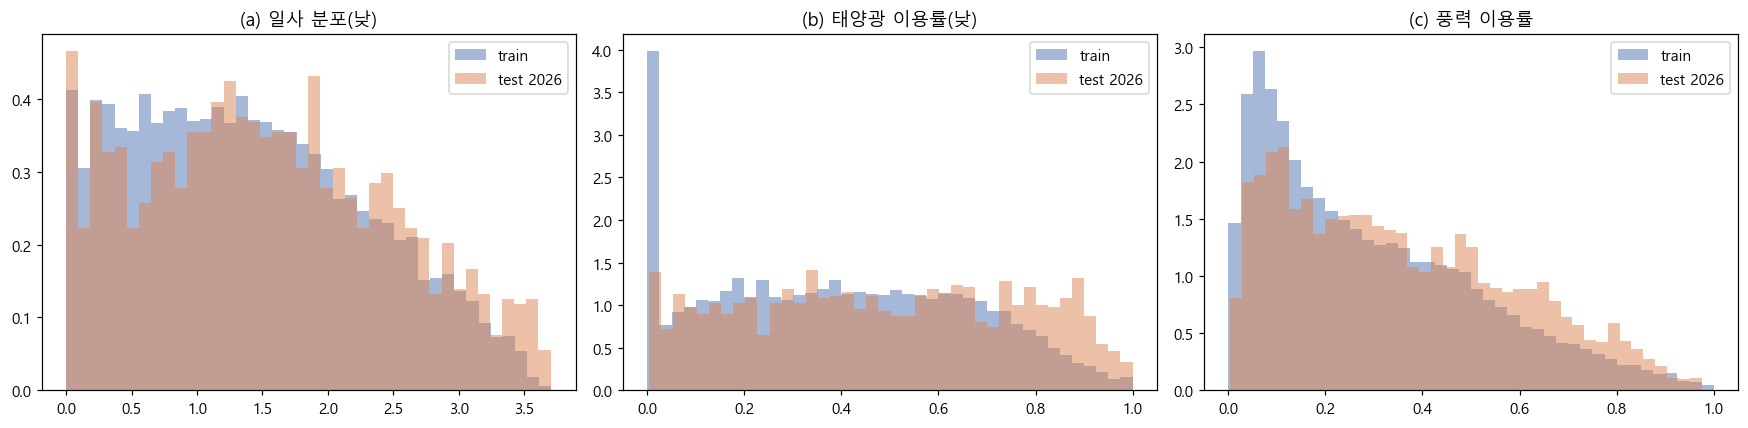

test 2026 가 train 범위(0.1~99.9%) 밖 비율:
  solar_rad                    0.69%
  gen_solar_utilization_kr     0.24%
  wind_spd                     0.21%
  gen_wind_utilization_kr      0.00%


In [9]:
tr = df[df.year<=2024]; te = df[df.year==2026]
fig, ax = plt.subplots(1,3, figsize=(16,4))
dtr = tr[(tr.hour>=8)&(tr.hour<=17)]; dte = te[(te.hour>=8)&(te.hour<=17)]
for name,g,c in [('train',dtr,'#4C72B0'),('test 2026',dte,'#DD8452')]:
    ax[0].hist(g.solar_rad.dropna(), bins=40, density=True, alpha=.5, label=name, color=c)
    ax[1].hist(g.gen_solar_utilization_kr.dropna(), bins=40, density=True, alpha=.5, label=name, color=c)
for name,g,c in [('train',tr,'#4C72B0'),('test 2026',te,'#DD8452')]:
    ax[2].hist(g.gen_wind_utilization_kr.dropna(), bins=40, density=True, alpha=.5, label=name, color=c)
ax[0].set_title('(a) 일사 분포(낮)'); ax[0].legend()
ax[1].set_title('(b) 태양광 이용률(낮)'); ax[1].legend()
ax[2].set_title('(c) 풍력 이용률'); ax[2].legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG,'6-0_covariate_shift.png'), bbox_inches='tight'); plt.show()
def outside(a, b, col):
    lo,hi = a[col].quantile([.001,.999]); return float(((b[col]<lo)|(b[col]>hi)).mean()*100)
print('test 2026 가 train 범위(0.1~99.9%) 밖 비율:')
for c in ['solar_rad','gen_solar_utilization_kr','wind_spd','gen_wind_utilization_kr']:
    print('  %-28s %.2f%%' % (c, outside(tr, te, c)))

## 8. net_load 구성 확인

서빙 net_load = 수요 − (태양광 + 풍력). 단 `renew_gen_total_kr` 에는 기타 신재생(수력·바이오 등)도
포함 → 태양광+풍력만으로 재구성한 net_load 와 DB `net_load_kr` 의 차(=기타 신재생)를 본다.

In [10]:
g = df.dropna(subset=['net_load_kr','real_demand_land','gen_solar_utilization_kr',
                       'gen_wind_utilization_kr','gen_solar_capacity_kr','gen_wind_capacity_kr']).copy()
g['solar_gen'] = g.gen_solar_utilization_kr * g.gen_solar_capacity_kr
g['wind_gen']  = g.gen_wind_utilization_kr  * g.gen_wind_capacity_kr
g['nl_recon']  = g.real_demand_land - g.solar_gen - g.wind_gen   # 태양광+풍력만
g['other_renew'] = g.nl_recon - g.net_load_kr                     # = 기타 신재생(+오차)
print('net_load_kr 평균 %.0f MW' % g.net_load_kr.mean())
print('재구성 net_load(수요-태양-풍력) 평균 %.0f MW' % g.nl_recon.mean())
print('차이(기타 신재생 추정) 평균 %.0f MW  중앙값 %.0f MW' % (g.other_renew.mean(), g.other_renew.median()))
print('corr(nl_recon, net_load_kr) = %.4f' % g.nl_recon.corr(g.net_load_kr))
print('\nrenew_gen_total_kr 평균 %.0f, 태양광+풍력 평균 %.0f, 기타(nre+hydro) 평균 %.0f'
      % (g.renew_gen_total_kr.mean(), (g.solar_gen+g.wind_gen).mean(),
         g[['gen_nre_kr','gen_hydro_kr']].sum(axis=1).mean()))

net_load_kr 평균 63278 MW
재구성 net_load(수요-태양-풍력) 평균 62611 MW
차이(기타 신재생 추정) 평균 -667 MW  중앙값 0 MW
corr(nl_recon, net_load_kr) = 0.9461

renew_gen_total_kr 평균 1422, 태양광+풍력 평균 1422, 기타(nre+hydro) 평균 2698


## 9. 요약 & 피처 후보 (모델 결정용 — §0.6 질의 입력)

아래를 근거로 6-A 착수 전 **최종 입력 피처를 사용자에게 확정**받는다.

In [11]:
ss = df.set_index('timestamp').gen_solar_utilization_kr
sw = df.set_index('timestamp').gen_wind_utilization_kr
day = df[(df.hour>=8)&(df.hour<=17)]
report = f'''# 6-0 EDA 요약 — 전국 신재생 → net_load (G-9)

## 데이터 / 타깃
- 타깃: gen_solar_utilization_kr · gen_wind_utilization_kr (이용률 0~1). 2020-01~2026-06, {len(df):,}행.
- 용량 표류: solar_cap {df.gen_solar_capacity_kr.min():.0f}→{df.gen_solar_capacity_kr.max():.0f}MW
  (×{df.gen_solar_capacity_kr.max()/df.gen_solar_capacity_kr.min():.1f}), wind_cap 완만 → **이용률 정규화 필수**(G-13).
- 학습창: train 2020–2024 / val 2025 / test 2026(부분).

## 시계열 구조
- 태양광: 강한 일주기(밤 0·정오 피크)+계절. 자기상관 lag24={ss.autocorr(24):+.3f}.
- 풍력: 자기상관 lag1={sw.autocorr(1):+.3f}→lag24={sw.autocorr(24):+.3f}→lag48={sw.autocorr(48):+.3f}
  (24h 이후 붕괴 → 재귀 롤링 장지평 불리, **direct 설계 근거**, 3단계 제주와 동형).

## 지점/공간평균 (G-13 검증)
- 태양광 선택3지점(영광·서산·포항) 평균 일사↔이용률 상관(낮) {day['solar_rad'].corr(day.gen_solar_utilization_kr):+.3f}.
- 풍력 선택3지점(대관령·영광·포항) 평균 풍속↔이용률 상관 {df['wind_spd'].corr(df.gen_wind_utilization_kr):+.3f}.

## 서빙 가능 피처 (★ 후처리 불가)
- 서빙 가능(O): solar_rad(radiation)·total_cloud·midlow_cloud·temp·wind_spd_10m·풍향 (지점별).
- 서빙 불가(X): humidity·rainfall·snow·cape·tcog ← forecast 없음.
  → **제주식 후처리(강수기반 solar_damping·tcog 보정) 불가**. 구름 변수로만 흐린날 대응.

## net_load 구성
- net_load = 수요 − 신재생. 태양광+풍력 외 기타 신재생(수력·바이오)이 일부 포함 → 9절 수치 참조.

## 다음 단계 결정거리 (사용자 확정, §0.6)
1. 모델 구조: LGBM-direct 다지평 단일(주력) + PatchTST D+1~3 비교(6-B) — G-13대로.
2. 최종 피처 후보:
   - SOLAR: solar_rad(3지점평균) + total_cloud_s + midlow_cloud_s + hour(sin/cos) + month/doy + (지점 raw?)
   - WIND : wind_spd(3지점평균) + wd_sin/cos + hour + month/doy + (year? 풍력 자기상관 약)
   - 공통: 이용률은 지평 무관(lag 없음) → 단일 모델이 전 지평 서빙(3단계 LGBM과 동일).
'''
with open(os.path.join(HERE,'REPORT_6-0_eda.md'),'w',encoding='utf-8') as f:
    f.write(report)
print(report)

# 6-0 EDA 요약 — 전국 신재생 → net_load (G-9)

## 데이터 / 타깃
- 타깃: gen_solar_utilization_kr · gen_wind_utilization_kr (이용률 0~1). 2020-01~2026-06, 56,352행.
- 용량 표류: solar_cap 2746→9441MW
  (×3.4), wind_cap 완만 → **이용률 정규화 필수**(G-13).
- 학습창: train 2020–2024 / val 2025 / test 2026(부분).

## 시계열 구조
- 태양광: 강한 일주기(밤 0·정오 피크)+계절. 자기상관 lag24=+0.871.
- 풍력: 자기상관 lag1=+0.987→lag24=+0.447→lag48=+0.243
  (24h 이후 붕괴 → 재귀 롤링 장지평 불리, **direct 설계 근거**, 3단계 제주와 동형).

## 지점/공간평균 (G-13 검증)
- 태양광 선택3지점(영광·서산·포항) 평균 일사↔이용률 상관(낮) +0.786.
- 풍력 선택3지점(대관령·영광·포항) 평균 풍속↔이용률 상관 +0.641.

## 서빙 가능 피처 (★ 후처리 불가)
- 서빙 가능(O): solar_rad(radiation)·total_cloud·midlow_cloud·temp·wind_spd_10m·풍향 (지점별).
- 서빙 불가(X): humidity·rainfall·snow·cape·tcog ← forecast 없음.
  → **제주식 후처리(강수기반 solar_damping·tcog 보정) 불가**. 구름 변수로만 흐린날 대응.

## net_load 구성
- net_load = 수요 − 신재생. 태양광+풍력 외 기타 신재생(수력·바이오)이 일부 포함 → 9절 수치 참조.

## 다음 단계 결정거리 (사용자 확정, §0.6)
1. 모델 구조: LGBM-direct 다지평 단일(주력) + PatchTST D+1~3 비교(6-B) — G-13대로.
2. 최종 피처 후보:
   - SOLAR: solar_ra